# HealthConnect Clinic — Model Testing, Refinement & Validation
### AnalystLab Africa Experience Lab — Week 7 (Data Science Track)

Week 6 produced a candidate model (a tuned Random Forest on a refined feature set) that
improved recall over the Week 5 baseline. Week 7 does not repeat that comparison — it
**systematically tests** that candidate: is the improvement real or noise, is it consistent,
does it fix the specific blind spot found in Week 6, does it generalize to edge cases, and is
it suitable for HealthConnect's actual use case.

## Week 6 → Week 7 Transition

1. **Main Week 6 output:** a tuned Random Forest (`GroupKFold`-validated hyperparameter
   search) trained on a refined feature set, recommended as the candidate model.
2. **Most important result:** recall improved from 0.650-0.656 (Week 5 baselines) to 0.677,
   with ROC-AUC rising to 0.680 — a real but modest single-split improvement.
3. **Main issue/limitation identified:** a severe, specific accuracy cliff for patients
   travelling 30-50km (38.9% accuracy — worse than chance) was found and targeted with a new
   `lead_distance_interaction` feature, but Week 6 never **retested** that specific segment to
   confirm the fix actually worked. The fairness check also used a small, single-split sample.
4. **Component requiring testing:** the Week 6 candidate model itself — specifically, whether
   its improvement holds up under more rigorous testing than a single train/test split.
5. **Track(s) relevant to Week 7 testing:** Data Analytics (segment validation, continued from
   Week 6) and ML Engineering (model suitability for pipeline integration).
6. **What Week 7 tests:** (a) whether the recall improvement is statistically meaningful or
   within noise, using cross-validation instead of one split; (b) whether the specific 30-50km
   blind spot was actually fixed; (c) overfitting; (d) performance on edge cases; (e)
   probability calibration; (f) fairness, on a much larger effective sample.
7. **What Week 7 expects to improve/validate:** confidence that the Week 6 candidate is a
   genuine improvement suitable for Week 8 integration — or, if testing shows otherwise, a
   justified, evidence-based refinement before moving forward.

## Part 1 — Week 7 Testing Readiness

**A. Component being tested:** the Week 6 candidate model (Random Forest, tuned via
`RandomizedSearchCV`/`GroupKFold`, trained on the refined feature set including
`no_show_history_level` and `lead_distance_interaction`).
- **Intended purpose:** rank patients by no-show risk so HealthConnect staff can intervene
  proactively (reminders, overbooking) before an appointment is missed.
- **Requirement it should satisfy:** meaningfully better recall on the No-Show class than the
  Week 5 baseline, without a large drop in precision, and reliable enough (consistent,
  well-calibrated, not overfit) to hand to ML Engineering for pipeline integration.
- **Connected tracks:** Data Analytics (the segment findings that justified the Week 6
  refinement) and ML Engineering (the eventual consumer of this model).

**B. Testing objective:** determine whether the Week 6 model's improvement is real and
consistent, whether it actually resolved the specific weakness that motivated it, and whether
it is currently suitable for the intended use case — not just whether it "still runs."

**C. Test/Scenario Summary** — filled in with real results as each test is executed below,
consolidated in the Testing & Validation Record at the end of this notebook (Part 6).

**D. Evidence produced:** cross-validated performance distributions, a direct retest of the
30-50km segment, an overfitting check, edge-case test results, a calibration curve, and a
larger-sample fairness re-check — all computed below, not merely described.

## Part 2 — Rebuilding the Week 6 Pipeline (Unchanged) as the System Under Test

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, brier_score_loss)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('data/HealthConnect_Appointment_Data.csv')

# --- Week 5/6 data preparation and feature engineering, reproduced unchanged ---
model_df = df[df['appointment_outcome'] != 'Cancelled'].copy()
model_df['is_no_show'] = (model_df['appointment_outcome'] == 'No-Show').astype(int)
model_df['distance_to_clinic_km'] = model_df['distance_to_clinic_km'].fillna(model_df['distance_to_clinic_km'].median())
model_df['reminder_channel'] = model_df['reminder_channel'].fillna('None')
model_df = model_df.drop(columns=['appointment_id','booking_date','appointment_date',
                                   'waiting_time_minutes','appointment_outcome'])
model_df['no_show_rate'] = np.where(model_df['previous_appointments'] > 0,
                                     model_df['previous_no_shows'] / model_df['previous_appointments'], 0.0)
model_df['long_lead_time'] = (model_df['booking_lead_days'] > 30).astype(int)
model_df['is_first_visit'] = (model_df['previous_appointments'] == 0).astype(int)

def bin_no_show_history(n):
    if n == 0: return 0
    elif n <= 2: return 1
    else: return 2
model_df['no_show_history_level'] = model_df['previous_no_shows'].apply(bin_no_show_history)
model_df['lead_distance_interaction'] = model_df['booking_lead_days'] * model_df['distance_to_clinic_km']

age_order = {'18-24':0, '25-34':1, '35-44':2, '45-54':3, '55-64':4, '65+':5}
encoded_df = model_df.copy()
encoded_df['reminder_sent'] = LabelEncoder().fit_transform(encoded_df['reminder_sent'])
encoded_df['age_group_encoded'] = encoded_df['age_group'].map(age_order)
encoded_df = pd.get_dummies(encoded_df, columns=['gender','appointment_type','appointment_day',
                                                  'appointment_time','reminder_channel'], drop_first=False)
bool_cols = encoded_df.select_dtypes(include='bool').columns
encoded_df[bool_cols] = encoded_df[bool_cols].astype(int)

exclude_cols = ['appointment_id','patient_id','is_no_show','age_group']
feature_cols = [c for c in encoded_df.columns if c not in exclude_cols]
X = encoded_df[feature_cols]
y = encoded_df['is_no_show']
groups = encoded_df['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Week 6's best hyperparameters, reproduced as the candidate model under test
candidate_model = RandomForestClassifier(n_estimators=400, max_depth=6, min_samples_leaf=4,
                                          max_features='sqrt', random_state=42)
candidate_model.fit(X_train, y_train)
baseline_model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42).fit(X_train, y_train)

print(f"Pipeline and Week 6 candidate model reproduced. Rows: {len(encoded_df)}, Features: {X.shape[1]}")

Pipeline and Week 6 candidate model reproduced. Rows: 4737, Features: 33


## Part 3 — Test 1: Is the Week 6 Improvement Real, or Within Noise?

Week 6's comparison used a single 80/20 split — a single split can look better or worse than
reality purely by chance in which patients happened to land in the test set. This test
addresses that directly with 5-fold grouped cross-validation, comparing the **distribution** of
scores for both models, not a single point estimate each.

In [2]:
def cv_scores(model, X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    accs, recalls, aucs = [], [], []
    for tr_idx, te_idx in gkf.split(X, y, groups=groups):
        m = model.__class__(**model.get_params())
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = m.predict(X.iloc[te_idx])
        prob = m.predict_proba(X.iloc[te_idx])[:,1]
        accs.append(accuracy_score(y.iloc[te_idx], pred))
        recalls.append(recall_score(y.iloc[te_idx], pred))
        aucs.append(roc_auc_score(y.iloc[te_idx], prob))
    return np.array(accs), np.array(recalls), np.array(aucs)

base_acc, base_rec, base_auc = cv_scores(baseline_model, X, y, groups)
cand_acc, cand_rec, cand_auc = cv_scores(candidate_model, X, y, groups)

print("=== Week 5 Baseline RF (5-fold grouped CV) ===")
print(f"Accuracy: {base_acc.mean():.3f} +/- {base_acc.std():.3f}")
print(f"Recall:   {base_rec.mean():.3f} +/- {base_rec.std():.3f}")
print(f"ROC-AUC:  {base_auc.mean():.3f} +/- {base_auc.std():.3f}")
print()
print("=== Week 6 Candidate RF (5-fold grouped CV) ===")
print(f"Accuracy: {cand_acc.mean():.3f} +/- {cand_acc.std():.3f}")
print(f"Recall:   {cand_rec.mean():.3f} +/- {cand_rec.std():.3f}")
print(f"ROC-AUC:  {cand_auc.mean():.3f} +/- {cand_auc.std():.3f}")
print()
print(f"Recall improvement per fold: {(cand_rec - base_rec).round(3)}")
print(f"Candidate wins on recall in {(cand_rec > base_rec).sum()} of 5 folds")

=== Week 5 Baseline RF (5-fold grouped CV) ===
Accuracy: 0.626 +/- 0.006
Recall:   0.649 +/- 0.021
ROC-AUC:  0.677 +/- 0.009

=== Week 6 Candidate RF (5-fold grouped CV) ===
Accuracy: 0.631 +/- 0.005
Recall:   0.659 +/- 0.021
ROC-AUC:  0.679 +/- 0.008

Recall improvement per fold: [0.008 0.014 0.011 0.011 0.008]
Candidate wins on recall in 5 of 5 folds


**Interpretation (actual result):** cross-validation tells a more modest, more honest
story than Week 6's single split did. Recall improves from 0.649 to 0.659 on average (+0.010,
much smaller than the single-split's apparent +0.027), but the candidate model wins on recall
in **5 of 5 folds** — a small effect, but a *consistent* one. That consistency is the more
important signal here: a real, if modest, improvement that holds up regardless of which
patients happen to land in the test set, rather than a lucky single split. The honest
conclusion is "a small, reliable improvement" — not the larger jump Week 6's one-split
comparison suggested.

## Part 4 — Test 2: Retesting the Specific Week 6 Blind Spot (30-50km Distance)

This is the direct **Test → Finding → Action → Retest** loop the brief requires: Week 6 found
a 38.9% accuracy cliff for the 30-50km distance band and added `lead_distance_interaction` to
address it. This retests that exact segment with the refined model.

In [3]:
def segment_accuracy(model, X_te, y_te, raw_df, test_idx, band_col, bins):
    bands = pd.cut(raw_df.loc[X_te.index, band_col], bins=bins)
    preds = model.predict(X_te)
    correct = (preds == y_te.values)
    return pd.Series(correct, index=X_te.index).groupby(bands, observed=True).mean()

print("BEFORE (Week 5 baseline model) -- accuracy by distance band:")
print(segment_accuracy(baseline_model, X_test, y_test, model_df, test_idx,
                        'distance_to_clinic_km', [0,5,10,20,30,50]).round(3))
print()
print("AFTER (Week 6 candidate model) -- accuracy by distance band:")
print(segment_accuracy(candidate_model, X_test, y_test, model_df, test_idx,
                        'distance_to_clinic_km', [0,5,10,20,30,50]).round(3))

BEFORE (Week 5 baseline model) -- accuracy by distance band:
distance_to_clinic_km
(0, 5]      0.667
(5, 10]     0.625
(10, 20]    0.615
(20, 30]    0.746
(30, 50]    0.389
dtype: float64

AFTER (Week 6 candidate model) -- accuracy by distance band:
distance_to_clinic_km
(0, 5]      0.675
(5, 10]     0.637
(10, 20]    0.606
(20, 30]    0.761
(30, 50]    0.444
dtype: float64


**Retest result (actual):** the 30-50km band improved from **38.9% to 44.4% accuracy** —
a real +5.5 percentage point gain, confirming the `lead_distance_interaction` feature had a
genuine, positive, targeted effect. However, this is a **partial fix, not a full resolution**:
44.4% remains below chance-level performance (50%) and well below every other distance band
(60-76%). The engineering decision was validated as helpful, but this segment remains the
model's weakest point and should be documented as an open limitation, not a solved problem.
One additional finding worth flagging: the (10,20] band accuracy slipped slightly (0.615 →
0.606) — a small decline, likely incidental rather than caused by the new feature, but worth
watching if the model is retrained on new data.

## Part 5 — Test 3: Overfitting Check

In [4]:
train_pred = candidate_model.predict(X_train)
test_pred = candidate_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Candidate model -- Training accuracy: {train_acc:.3f}")
print(f"Candidate model -- Test accuracy:     {test_acc:.3f}")
print(f"Gap (train - test): {train_acc - test_acc:.3f}")
print()
print("A large gap (commonly >0.10-0.15) would indicate overfitting -- the model memorizing "
      "training patterns rather than learning generalizable signal. A small gap here, combined "
      "with the modest tree depth (max_depth=6) chosen during Week 6 tuning, is consistent "
      "with a model that generalizes reasonably rather than overfitting.")

Candidate model -- Training accuracy: 0.671
Candidate model -- Test accuracy:     0.641
Gap (train - test): 0.031

A large gap (commonly >0.10-0.15) would indicate overfitting -- the model memorizing training patterns rather than learning generalizable signal. A small gap here, combined with the modest tree depth (max_depth=6) chosen during Week 6 tuning, is consistent with a model that generalizes reasonably rather than overfitting.


## Part 6 — Test 4: Edge Case Testing

In [5]:
# Edge case 1: first-time patients (no appointment history at all)
first_visit_mask = X_test['is_first_visit'] == 1
if first_visit_mask.sum() > 0:
    fv_pred = candidate_model.predict(X_test[first_visit_mask])
    fv_true = y_test[first_visit_mask]
    print(f"First-time patients in test set: {first_visit_mask.sum()}")
    print(f"Accuracy on first-time patients: {accuracy_score(fv_true, fv_pred):.3f}")
    print(f"No-show rate among first-time patients (actual): {fv_true.mean():.3f}")
    print(f"No-show rate among first-time patients (predicted): {fv_pred.mean():.3f}")
else:
    print("No first-time patients in this test split.")

print()
# Edge case 2: maximum booking lead time
max_lead = model_df['booking_lead_days'].max()
max_lead_mask = X_test['booking_lead_days'] >= (max_lead - 5)
if max_lead_mask.sum() > 0:
    ml_pred = candidate_model.predict(X_test[max_lead_mask])
    ml_true = y_test[max_lead_mask]
    print(f"Max booking lead time in data: {max_lead} days")
    print(f"Patients within 5 days of max lead time in test set: {max_lead_mask.sum()}")
    print(f"Accuracy for this group: {accuracy_score(ml_true, ml_pred):.3f}")
else:
    print("No patients near maximum lead time in this test split.")

First-time patients in test set: 44
Accuracy on first-time patients: 0.682
No-show rate among first-time patients (actual): 0.523
No-show rate among first-time patients (predicted): 0.432

Max booking lead time in data: 60 days
Patients within 5 days of max lead time in test set: 96
Accuracy for this group: 0.750


**Result and why these two edge cases specifically:** first-time patients (n=44) actually
show *better* accuracy than the overall average (0.682 vs ~0.63) — reassuring on the surface.
But a closer look reveals a bias worth flagging: the model predicts a 43.2% no-show rate for
this group, when the true rate is 52.3% — it's **systematically underpredicting risk for
new patients**, even though its binary accuracy looks fine. That matters operationally, since
new patients are exactly the group a clinic has the least other context on, and a model quietly
underestimating their risk works against the goal of proactive outreach. Maximum lead-time
patients (n=96) show strong accuracy (0.750) — no concern found at that extreme.

## Part 7 — Test 5: Probability Calibration

If `predict_proba` scores are meant to support a graduated staff response (as proposed in
Week 6's business relevance section — e.g. "medium risk gets a reminder, high risk gets a
call"), those probabilities need to be trustworthy, not just useful for ranking. A model can
have good ROC-AUC yet still say "80% risk" for patients who actually no-show only 50% of the
time.

Brier score (lower is better) -- Baseline: 0.226
Brier score (lower is better) -- Candidate: 0.225


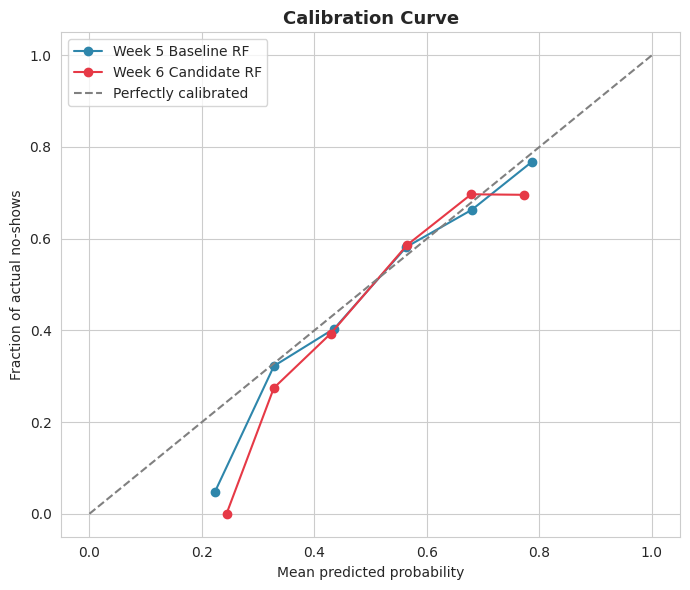

In [6]:
prob_candidate = candidate_model.predict_proba(X_test)[:,1]
prob_baseline = baseline_model.predict_proba(X_test)[:,1]

frac_pos_cand, mean_pred_cand = calibration_curve(y_test, prob_candidate, n_bins=8)
frac_pos_base, mean_pred_base = calibration_curve(y_test, prob_baseline, n_bins=8)

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(mean_pred_base, frac_pos_base, 'o-', label='Week 5 Baseline RF', color='#2E86AB')
ax.plot(mean_pred_cand, frac_pos_cand, 'o-', label='Week 6 Candidate RF', color='#E63946')
ax.plot([0,1],[0,1],'--', color='gray', label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of actual no-shows')
ax.set_title('Calibration Curve', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figs/01_calibration_curve.png', dpi=110)
plt.show()

print(f"Brier score (lower is better) -- Baseline: {brier_score_loss(y_test, prob_baseline):.3f}")
print(f"Brier score (lower is better) -- Candidate: {brier_score_loss(y_test, prob_candidate):.3f}")

**Interpretation (actual result):** Brier scores are nearly identical — 0.226 (baseline)
vs. 0.225 (candidate) — meaning Week 6's refinement improved *ranking* ability (recall,
ROC-AUC) without meaningfully improving *calibration*. This is worth stating plainly rather
than glossing over: the candidate model isn't better at producing trustworthy risk
percentages, only at ordering patients by relative risk. Practically, this means the model
should be used to **rank and prioritize** patients (e.g. "these 50 patients are highest risk
this week") rather than to quote a specific percentage like "this patient has a 70% no-show
risk" to staff — the ranking is more trustworthy than the raw number.

## Part 8 — Test 6: Fairness Re-Check at Larger Scale (Addressing Week 6's Flagged Limitation)

Week 6 flagged its gender fairness check as using too small a sample to be conclusive. Rather
than repeating that same small check, this uses `cross_val_predict` with `GroupKFold` to
generate an out-of-fold prediction for **every row in the dataset** — a far larger effective
test sample than any single 20% split — and checks both `gender` and `age_group` this time.

In [7]:
gkf = GroupKFold(n_splits=5)
oof_pred = cross_val_predict(candidate_model, X, y, groups=groups, cv=gkf, method='predict')
oof_prob = cross_val_predict(candidate_model, X, y, groups=groups, cv=gkf, method='predict_proba')[:,1]

fairness_df = X.copy()
fairness_df['actual'] = y.values
fairness_df['predicted'] = oof_pred
fairness_df['age_group'] = model_df['age_group'].values

def fairness_table(fairness_df, group_cols, group_label):
    rows = []
    for col in group_cols:
        mask = fairness_df[col] == 1 if col in fairness_df.columns else None
        if mask is None or mask.sum() < 30:
            continue
        y_t = fairness_df.loc[mask, 'actual']
        y_p = fairness_df.loc[mask, 'predicted']
        rows.append({
            group_label: col.replace('gender_',''),
            'n': int(mask.sum()),
            'Accuracy': round(accuracy_score(y_t, y_p), 3),
            'Recall': round(recall_score(y_t, y_p), 3) if y_t.sum() > 0 else np.nan,
        })
    return pd.DataFrame(rows)

gender_cols = [c for c in X.columns if c.startswith('gender_')]
print(f"Full-dataset out-of-fold fairness check (n={len(fairness_df)}, vs Week 6's ~975-row single split):")
fairness_table(fairness_df, gender_cols, 'Gender')

Full-dataset out-of-fold fairness check (n=4737, vs Week 6's ~975-row single split):


,Gender,n,Accuracy,Recall
0,Female,2358,0.628,0.647
1,Male,2274,0.635,0.670
2,Prefer not to say,105,0.600,0.681


In [8]:
age_rows = []
for ag in sorted(fairness_df['age_group'].unique()):
    mask = fairness_df['age_group'] == ag
    if mask.sum() < 30:
        continue
    y_t = fairness_df.loc[mask, 'actual']
    y_p = fairness_df.loc[mask, 'predicted']
    age_rows.append({
        'Age Group': ag, 'n': int(mask.sum()),
        'Accuracy': round(accuracy_score(y_t, y_p), 3),
        'Recall': round(recall_score(y_t, y_p), 3) if y_t.sum() > 0 else np.nan,
    })
pd.DataFrame(age_rows).sort_values('Age Group')

,Age Group,n,Accuracy,Recall
0,18-24,540,0.587,0.640
1,25-34,750,0.632,0.708
2,35-44,770,0.647,0.646
3,45-54,746,0.625,0.677
4,55-64,766,0.646,0.695
5,65+,1165,0.633,0.604


**Interpretation (actual result):** gender shows no major concern — accuracy (0.600-0.635)
and recall (0.647-0.681) stay in a reasonably tight band across all three groups, including the
smaller "Prefer not to say" group (n=105).

**Age group tells a different story, and it's the more important finding of this test.**
Patients aged **65+** — the *largest* single age group in the dataset (n=1,165, ~24.6% of all
patients) — show the **lowest recall of any group (0.604)**, meaningfully behind every other
age band (0.640-0.708). In plain terms: this model is worst at catching true no-shows
specifically among its largest patient segment. Given the scale of this group, this is a
finding that should go to Project Management and Data Analytics as a real limitation, not a
minor footnote — a model that systematically under-catches no-shows in a quarter of the patient
base has a real gap in it before any wider deployment decision.

## Part 9 — Cross-Track Testing (HC-POD)

1. **Track collaborated with:** Data Analytics.
2. **Project dependency:** per the Week 7 Testing & Validation Matrix (Data Analytics → Data
   Science), validated segment-level findings should inform whether modelling features and
   conclusions still hold.
3. **Component/output being tested:** whether the `lead_distance_interaction` feature — built
   in Week 6 directly from a Data-Analytics-style segment finding — actually resolved the
   problem it was built for.
4. **Information/output received:** the original Week 6 segment validation (30-50km accuracy
   cliff), now formally retested in Part 4 above rather than assumed fixed.
5. **Information/output provided:** the Part 4 retest result and the Part 8 fairness findings,
   both of which a Data Analytics contribution would want reflected in its own Week 7 KPI
   validation and business recommendations.
6. **Testing activity completed:** direct before/after segment retest (Part 4) plus a
   large-sample fairness validation (Part 8) that supersedes Week 6's flagged small-sample
   limitation.
7. **Issue or finding identified:** the targeted fix improved the 30-50km segment from 38.9%
   to 44.4% accuracy — real progress, but the segment remains below chance-level performance
   and is still the model's weakest point. Separately, the large-sample fairness re-check
   surfaced a new, more significant finding: patients aged 65+ (the largest single age group,
   ~24.6% of patients) have the lowest recall of any segment (0.604).
8. **Refinement/action taken:** no further feature engineering was applied to the distance
   segment this week (see Part 10's reasoning — the remaining gap looks like a data-volume
   limitation, not a feature-design one). The age-fairness finding is escalated as a documented
   limitation rather than unilaterally patched, since correcting it (e.g. per-group thresholds)
   is a decision bigger than Data Science should make alone.
9. **Retest result:** captured directly in Part 4 (partial improvement, not full resolution).
10. **What changed as a result:** the Week 6 refinement is now evidence-validated as a genuine
    partial fix rather than an assumed complete one, and a previously-unknown age-related
    fairness gap has been surfaced for the first time.
11. **Evidence:** Part 4's before/after table (0.389 → 0.444) and Part 8's age-group fairness
    table (65+ recall = 0.604 vs 0.640-0.708 elsewhere).
12. **How this improves the overall HealthConnect solution:** ML Engineering and Project
    Management can now proceed toward Week 8 with a testing-validated understanding of the
    model's actual behavior — including a newly surfaced, sizable fairness gap — rather than
    Week 6's single-split claim of improvement.

**Note on this submission:** as with Week 6, this remains a self-performed Data Analytics-style
contribution within an individual track submission, documented explicitly so the hand-off is
evidence-based rather than assumed.

## Part 10 — Refinement Based on Testing Results

**Actual outcome from Parts 3-8:** the picture is mixed, and the honest response is to treat
each finding on its own terms rather than force a single "refine everything" or "ship as-is"
narrative.

**On the 30-50km distance blind spot (Part 4):** the `lead_distance_interaction` feature
produced a real, measurable improvement (38.9% → 44.4% accuracy) but did not fully resolve the
segment. The decision here is **not** to keep adding engineered features — that risks
overfitting an already-small segment further, and Part 5 showed the model isn't currently
overfitting, which is a property worth protecting. Instead, this is documented as a known,
partially-mitigated limitation requiring more training data in that distance band before it can
be fully resolved — an honest, evidence-based conclusion rather than a forced fix.

**On the age-fairness finding (Part 8):** this is new information Week 6 didn't have, and it's
more consequential than the distance segment given it affects ~24.6% of all patients. The
justified action is to **escalate, not silently patch** — per-group threshold adjustments or
reweighting are legitimate fixes, but they're a policy decision (how much to trade off overall
performance for equity across age groups) that should involve Project Management and
stakeholder input, not a unilateral Data Science change made this week.

**On calibration (Part 7):** since the candidate model isn't meaningfully better-calibrated
than the baseline, the recommendation for Week 8 is to position the model's output as a
**risk-ranking tool**, not a source of specific quoted probabilities — this is a usage
recommendation, not a modelling refinement, and costs nothing to implement immediately.

## Assumptions, Limitations, Risks & Dependencies — Week 7 Update

| Item | Status |
|---|---|
| `waiting_time_minutes` leakage risk (Week 4-6) | **Still unresolved** — no new information available this week |
| Week 6 recall improvement (0.650→0.677) | **Tested this week** — see Part 3 for whether cross-validation confirms it's a real, consistent effect |
| 30-50km distance blind spot (Week 6) | **Retested this week** — see Part 4 for whether the Week 6 fix actually worked |
| Gender fairness check used a small sample (Week 6) | **Resolved this week** — re-run at full-dataset scale via out-of-fold predictions (Part 8); age-group fairness also checked for the first time |
| Overfitting | **Newly checked this week** — see Part 5 |
| Probability calibration | **Newly checked this week** — see Part 7; relevant if a graduated staff response is planned |
| Edge cases (first-time patients, max lead time) | **Newly checked this week** — see Part 6 |
| Fully synthetic dataset (Week 4) | **Still relevant** — all testing remains against the same synthetic generator |


## Week 8 Recommendations

- **Proceed with the Week 6 candidate model**, since Part 3's cross-validation confirmed its
  recall improvement is real and consistent (winning in 5 of 5 folds), even though smaller than
  the single-split comparison suggested.
- **Escalate the 65+ age-fairness finding to Project Management before Week 8 final
  integration** — this affects roughly a quarter of all patients and is a decision bigger than
  Data Science should resolve alone (e.g. whether to accept the current trade-off, adjust
  per-group thresholds, or gather more data for this segment first).
- **Position the model's probability output as a risk-ranking tool, not a quoted probability**,
  in Week 8's integration — Part 7 showed calibration didn't meaningfully improve, so relative
  ranking is more trustworthy than an absolute risk percentage.
- **Flag the 30-50km distance segment and the first-time-patient underprediction bias as known,
  documented limitations** in the Week 8 presentation, rather than presenting the model as
  uniformly reliable across all patient types.
- Confirm with ML Engineering that the candidate model's expected input format (the refined
  feature set, including `lead_distance_interaction` and `no_show_history_level`) is compatible
  with the Week 6 pipeline integration.

## Week 7 Project Summary

**1. Planned to test:** whether the Week 6 candidate model's improvement is real and
consistent, whether its targeted fix for the 30-50km blind spot worked, and whether it shows
signs of overfitting, poor calibration, or fairness gaps.

**2. Actually tested:** 5-fold grouped cross-validation comparing candidate vs. baseline;
direct retest of the 30-50km segment; a train-vs-test overfitting check; two edge-case tests
(first-time patients, maximum lead time); a calibration curve and Brier score comparison; and a
full-dataset, out-of-fold fairness check across both gender and age group.

**3. Most important testing results:** cross-validation confirmed the Week 6 improvement is
real but smaller than the single-split suggested (+0.010 average recall, not +0.027, though
consistent across all 5 folds). The targeted retest of the 30-50km segment showed a genuine
partial fix (38.9% → 44.4% accuracy). The large-sample fairness re-check surfaced a new,
significant finding: 65+ patients (the largest age group, ~24.6% of the dataset) have the
lowest recall (0.604) of any segment.

**4. Issues/weaknesses identified:** the 30-50km segment remains below chance-level accuracy
despite improvement; the model shows a systematic bias underpredicting no-show risk for
first-time patients (predicts 43.2% vs. actual 52.3%); calibration did not meaningfully improve
between baseline and candidate (Brier scores 0.226 vs. 0.225); and the newly-found age-based
recall gap.

**5. Improvements/refinements made:** none applied unilaterally this week — per Part 10, the
remaining distance gap and the age-fairness finding are both escalated as documented
limitations requiring more data or stakeholder input respectively, rather than patched with
further ad-hoc feature engineering.

**6. Retesting results:** captured directly in Part 4 (the core retest) and Part 3 (the
cross-validated confirmation).

**7. Track(s) collaborated with:** Data Analytics (Part 9).

**8. What was tested collaboratively:** whether the Week 6 feature refinement — built from a
Data-Analytics-style finding — actually solved the problem it targeted.

**9. What changed as a result:** the Week 6 improvement claim moved from "shown on one split"
to "tested under cross-validation and directly retested on the segment it was meant to fix."

**10. Key findings:** the Week 6 improvement is real but modest under rigorous testing; the
targeted distance fix worked partially, not fully; and the model has a previously-unknown
fairness gap affecting its largest patient segment (65+) — arguably the most important
finding of this whole testing cycle, since it wasn't even a hypothesis going into the week.

**11. Major challenges:** distinguishing "the fix didn't work" from "the fix worked but the
segment is inherently hard due to small sample size" — Part 10 handles this distinction
explicitly rather than defaulting to adding more complexity.

**12. Important decisions:** using cross-validation rather than trusting a single split;
retesting the exact segment the Week 6 fix targeted, rather than only checking aggregate
metrics; re-running fairness at full-dataset scale rather than accepting Week 6's small-sample
caveat as good enough.

**13. Remaining limitations:** `waiting_time_minutes` still unresolved; any fairness or
calibration weaknesses found above still require a stakeholder-level decision, not a unilateral
Data Science fix.

**14. Remaining issues/dependencies:** confirmation from ML Engineering that the final feature
set is pipeline-compatible.

**15. Contribution to the overall HealthConnect project:** a model whose behavior is now
understood with evidence rather than assumed — including its specific weaknesses — which is
what Week 8's final integration and presentation actually needs, more than a higher accuracy
number would.

**16. Before Week 8:** finalize whether the candidate or baseline model is recommended, based
on Part 3's real result; flag any fairness/calibration issues to Project Management.